In [13]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pingouin as pg
import seaborn as sns
import statsmodels.api as sm
from scipy import stats

### Module 5.1: EDA is Hypothesis Generation

Most people think EDA is just "making plots". This is wrong.

EDA is **detective work**. You are an investigator arriving at a crime scene. The data is your set of clues. You are not trying to *prove* a case (that is formal modeling, Module 7). You are trying to *understand the scene* and form your first theories (hypotheses).

* **Bad EDA:** "I will plot `SalePrice`." (A passive action).
* **Statistician's EDA:** "I *hypothesize* that `SalePrice` is not normally distributed, because it is a financial variable and is likely right-skewed. I will plot its histogram to confirm this."

Every plot, every `.mean()`, every `.corr()` is an *active question* you are asking of the data. Your goal is to find patterns, anomalies, and relationships, which you will then test rigorously in Module 7.

### Module 5.2: Measures of Centrality (The "Center")

The first question you ask of any numeric variable is: "What is its typical, or central, value?" There are three ways to answer this, and each tells a different story.

Let $X$ be a set of $n$ data points: $X = \{x_1, x_2, \dots, x_n\}$.

#### 1. The Mean ($\mu$)
* **What it is:** The arithmetic average.
* **The Math:** $\mu = \frac{1}{n} \sum_{i=1}^{n} x_i = \frac{x_1 + x_2 + \dots + x_n}{n}$
* **The Story it Tells:** The "center of gravity" of your data. If your data points were physical weights on a beam, the mean is the exact point where the beam would balance.
* **The Fatal Flaw:** The mean is **highly sensitive to outliers**.
    * **Data:** `[1, 2, 3, 4, 100]`
    * **Mean:** $(1+2+3+4+100) / 5 = 110 / 5 = 22$
    * **The Problem:** The "typical" value is clearly around 2-3, but the outlier `100` has *dragged* the mean all the way to 22. The mean is now a *misleading* description of the center.
* **When to use it:** Only when your data is **symmetric** and does not have extreme outliers (e.g., normally distributed data like heights, exam scores).

#### 2. The Median
* **What it is:** The 50th percentile. The exact middle value after you sort the data.
* **The Math:** $\text{Median}(X) = \text{Value of the } (\frac{n+1}{2})\text{-th item in the sorted list}$
* **The Story it Tells:** The "center of position". It is the value that splits your data in half: 50% of your data is below it, and 50% is above it.
* **The Great Strength:** The median is **robust to outliers**.
    * **Data:** `[1, 2, 3, 4, 100]`
    * **Sorted:** `[1, 2, **3**, 4, 100]`
    * **Median:** 3
    * **The Insight:** The median (3) is a *far* more honest and representative measure of the "typical" value than the mean (22).
* **When to use it:** Almost *always* for skewed data, especially financial data (e.g., "Median Household Income", "Median `SalePrice`").

#### 3. The Mode
* **What it is:** The most frequently occurring value.
* **The Story it Tells:** The "most popular" or "most common" outcome.
* **When to use it:** Primarily for **categorical** data (e.g., the `Mode` of the `Neighborhood` column is "North Ames"). It can also be used to describe *peaks* in numeric data (e.g., "bimodal" data has two modes).

**Statistician's Rule:** If the `Mean` is significantly different from the `Median`, your data is **skewed**.


### Module 5.3: Measures of Spread (The "Variability")

The "center" is only half the story. The other half is: "How spread out is my data?" A dataset with a mean of 10 and a spread of 1 is totally different from one with a mean of 10 and a spread of 100.

#### 1. Variance ($\sigma^2$)
* **What it is:** The average of the *squared differences from the Mean*.
* **The Math:** $\sigma^2 = \frac{1}{n} \sum_{i=1}^{n} (x_i - \mu)^2$
* **The Story it Tells:** It measures the "total energy" or "total variability" in the system. It is the single most important measure of spread in statistics and is the foundation of ANOVA (Module 7).
* **The Problem:** The units are *weird*. If your data is in dollars (\$), the variance is in *dollars-squared* ($\$^2$). This is not intuitive.

#### 2. Standard Deviation ($\sigma$)
* **What it is:** The *square root* of the Variance.
* **The Math:** $\sigma = \sqrt{\sigma^2} = \sqrt{\frac{1}{n} \sum_{i=1}^{n} (x_i - \mu)^2}$
* **The Story it Tells:** This is the magic. By taking the square root, we return to the *original units* of the data. If your data is in dollars, the standard deviation is also in dollars.
* **The Meaning:** It measures the "typical distance" that a data point is from the mean.
* **When to use it:** This is the default measure of spread *when your data is normal* (symmetric). The "68-95-99.7" rule for the normal distribution is defined by standard deviations.

#### 3. Interquartile Range (IQR)
* **What it is:** The range (distance) between the 75th percentile ($Q_3$) and the 25th percentile ($Q_1$).
* **The Math:** $\text{IQR} = Q_3 - Q_1$
* **The Story it Tells:** It describes the spread of the "middle 50%" of your data, completely ignoring the extremes.
* **The Great Strength:** Just like the Median, the IQR is **robust to outliers**. The `boxplot` we used in Module 4 is built entirely on the Median and the IQR.
* **When to use it:** This is the best measure of spread to report *alongside the Median* for skewed data.

**Statistician's Rule:**
* For **symmetric** data, report the **Mean and Standard Deviation**.
* For **skewed** data, report the **Median and Interquartile Range (IQR)**.


### Module 5.4: The Shape of Data (Skewness & Kurtosis)

These are two advanced measures that describe the *character* of your distribution.

1.  **Skewness:**
    * **What it is:** A measure of *asymmetry*.
    * **The Math:** It is based on the *cubed* deviations from the mean: $\frac{\frac{1}{n} \sum (x_i - \mu)^3}{(\sigma^2)^{3/2}}$
    * **The Meaning (Simplified):**
        * **Skew = 0:** Perfectly symmetric (e.g., a Normal distribution). `Mean == Median`.
        * **Skew > 0 (Positive/Right-Skew):** A long "tail" of high-value outliers pulls the `Mean` *to the right* of the `Median`. (e.g., `SalePrice`, `Income`).
        * **Skew < 0 (Negative/Left-Skew):** A long "tail" of low-value outliers pulls the `Mean` *to the left* of the `Median`. (e.g., Exam scores where most people do well, but a few fail badly).
    * **Statistician's Rule:** This number is your "go-to" diagnostic. If `skewness > 1` (or `<-1`), your data is highly skewed, and you *must* consider a transformation (like `np.log()`) before using any models that assume normality (like Linear Regression).

2.  **Kurtosis:**
    * **What it is:** A measure of the "tailedness" and "peakedness" of the distribution.
    * **The Math:** Based on the *fourth power* of deviations: $\frac{\frac{1}{n} \sum (x_i - \mu)^4}{(\sigma^2)^2}$
    * **The Meaning:** High kurtosis means more of the data's variance is caused by *infrequent, extreme outliers* (a "pointy" peak and "fat tails"). Low kurtosis means the variance is caused by *frequent, modest deviations* (a "flat" peak and "thin tails").
    * **Statistician's Rule:** This is a key metric for risk analysis (e.g., in finance). High kurtosis ("fat tails") means you are *more likely* to see extreme, "Black Swan" events than a normal distribution would predict.

### Module 5.5: Correlation vs. Causation

This is the most important *logical* principle in all of statistics.

* **Correlation:** Two variables tend to move together.
* **Causation:** A change in one variable *causes* a change in another.

**The Example:**
You will find a very high, positive correlation between "ice cream sales" and "drownings".
* **The `data-analyst` (Bad):** "Ice cream sales cause drownings!"
* **The `statistician` (Good):** "This is a spurious correlation. A third, hidden variable (a **confounding variable**)—'summer heat'—is causing *both* to increase. There is no causal link between them."

**Statistician's Rule:** Correlation does not imply causation. It only tells you *what* is happening, not *why*. Never, ever claim causation from a correlation alone.

### Module 5.6: Correlation Metrics

This brings us to *how* we measure correlation. The tool you choose depends on the *type* of relationship.

#### 1. Pearson's $r$ (The Default)
* **What it is:** The standard correlation coefficient. It measures the strength and direction of a **linear** relationship.
* **The Math:** It is the *covariance* of the two variables, normalized by their standard deviations.
    $r = \frac{\sum (x_i - \mu_x)(y_i - \mu_y)}{\sqrt{\sum (x_i - \mu_x)^2 \sum (y_i - \mu_y)^2}}$
* **The Meaning:** The value is always between -1 and 1.
    * $r = 1.0$: Perfect positive *linear* relationship.
    * $r = -1.0$: Perfect negative *linear* relationship.
    * $r = 0.0$: No *linear* relationship.
* **The Fatal Flaw:** Pearson's $r$ is *only* for linear relationships. If the data has a perfect *U-shape*, Pearson's $r$ will be $\approx 0$, falsely telling you there is "no relationship".

#### 2. Spearman's $\rho$ (The Robust Alternative)
* **What it is:** A non-parametric measure of correlation.
* **The Math:** Instead of using the *values* of $x$ and $y$, it first converts them to *ranks* (1st, 2nd, 3rd, etc.) and then calculates the Pearson correlation of those *ranks*.
* **The Story it Tells:** It measures the strength and direction of a **monotonic** relationship.
* **What is "Monotonic"?** As one variable increases, the other *consistently* increases or *consistently* decreases, but not necessarily in a straight line.
* **Statistician's Rule:**
    * Use **Pearson** when you are specifically testing for a *linear* relationship (e.g., for linear regression) and your data is not horribly skewed.
    * Use **Spearman** when your data is *skewed*, has *outliers*, or you are testing for a *non-linear* (but still directional) relationship. It is the more robust, "safer" choice.

### Summary of Moment 1

We have now established the full theoretical basis for EDA:
* **Center:** Mean (for symmetric), Median (for skewed).
* **Spread:** Standard Deviation (for symmetric), IQR (for skewed).
* **Shape:** Skewness (asymmetry), Kurtosis (tailedness).
* **Relationships:** Correlation (Pearson for linear, Spearman for monotonic) does not equal Causation.

### The Analytical Brief

**Project:** Ames Housing Price Analysis
**Objective:** To understand the primary drivers of `SalePrice` in the Ames, Iowa housing market.
**Role:** You are the lead Data Scientist. The business wants to know what makes a house expensive. You must investigate the data, identify the most important factors, and present a full statistical report on your findings.

### Minimal Starter Code (Dataset Only)

Here is the code to load the data. It has 79 features and numerous missing values. How you handle them is your first analytical decision.

In [14]:
from sklearn.datasets import fetch_openml

# Load the Ames Housing dataset
housing = fetch_openml(name="house_prices", as_frame=True)

# Combine features and target for a complete DataFrame
ames_df = housing.data.copy()
ames_df["SalePrice"] = housing.target

print(f"Dataset loaded with shape: {ames_df.shape}")

Dataset loaded with shape: (1460, 81)


### Tasks (The "Statistician's" Workflow)


**1. Initial Data Triage and Cleaning Strategy**

  * **Goal:** Understand the battlefield. What is the shape of the data? What are the data types? How severe is the missing data problem?
  * **Deliverable:**
      * A summary of the dataset (shape, dtypes).
      * A clear, written **"Missing Data Strategy."** You must identify which columns have missing data and state your plan. Will you drop the column? Drop the row? Impute with a mean/median/mode? Justify your choices for at least two key features (e.g., `LotFrontage`, `GarageType`).

In [15]:
from helpers.categorical import (
	get_categorical_columns,
	make_overview,
	per_column_tables,
)

cat_cols = get_categorical_columns(ames_df)
overview = make_overview(df=ames_df, columns=cat_cols)
table = per_column_tables(df=ames_df, columns=cat_cols)

In [16]:
from helpers.missing import missing_data_summary

missing = missing_data_summary(df=ames_df)

display(missing)

,Data Type,Missing Count,Missing %,Non-Missing Count
PoolQC,object,1453,99.52,7
MiscFeature,object,1406,96.30,54
Alley,object,1369,93.77,91
Fence,object,1179,80.75,281
FireplaceQu,object,690,47.26,770
LotFrontage,float64,259,17.74,1201
GarageCond,object,81,5.55,1379
GarageType,object,81,5.55,1379
GarageYrBlt,float64,81,5.55,1379
GarageFinish,object,81,5.55,1379


In [17]:
from sklearn.impute import SimpleImputer

missing_cat = missing[missing["Data Type"] == "object"].index.to_list()
missing_float = missing[missing["Data Type"] == "float64"].index.to_list()

# Create separate imputers for categorical and numeric columns
cat_imputer = SimpleImputer(strategy="constant", fill_value="None")
float_imputer = SimpleImputer(strategy="constant", fill_value=0)

# Apply imputation
ames_df_imputed = ames_df.copy()

# Impute categorical columns
ames_df_imputed[missing_cat] = cat_imputer.fit_transform(ames_df[missing_cat])

# Impute float columns
ames_df_imputed[missing_float] = float_imputer.fit_transform(ames_df[missing_float])


In [18]:
ames_df_imputed

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,None,Reg,Lvl,AllPub,...,0,None,None,None,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,None,Reg,Lvl,AllPub,...,0,None,None,None,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,None,IR1,Lvl,AllPub,...,0,None,None,None,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,None,IR1,Lvl,AllPub,...,0,None,None,None,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,None,IR1,Lvl,AllPub,...,0,None,None,None,0,12,2008,WD,Normal,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,1456,60,RL,62.0,7917,Pave,None,Reg,Lvl,AllPub,...,0,None,None,None,0,8,2007,WD,Normal,175000
1456,1457,20,RL,85.0,13175,Pave,None,Reg,Lvl,AllPub,...,0,None,MnPrv,None,0,2,2010,WD,Normal,210000
1457,1458,70,RL,66.0,9042,Pave,None,Reg,Lvl,AllPub,...,0,None,GdPrv,Shed,2500,5,2010,WD,Normal,266500
1458,1459,20,RL,68.0,9717,Pave,None,Reg,Lvl,AllPub,...,0,None,None,None,0,4,2010,WD,Normal,142125


**2. Deep Dive: The Target Variable (`SalePrice`)**

  * **Goal:** Before analyzing its *drivers*, you must deeply understand the `SalePrice` itself.
  * **Deliverable:**
      * A statistical and visual analysis of the `SalePrice` distribution.
      * **Answer this:** What is the "typical" house price? (You must decide if the mean or median is a more honest statistic).
      * **Answer this:** Is the data symmetric or skewed? (Provide statistical proof, not just a visual guess).
      * **Answer this:** What are the implications of this shape for any future linear models? What transformation (if any) would you recommend, and *show* the "before and after" visual proof?

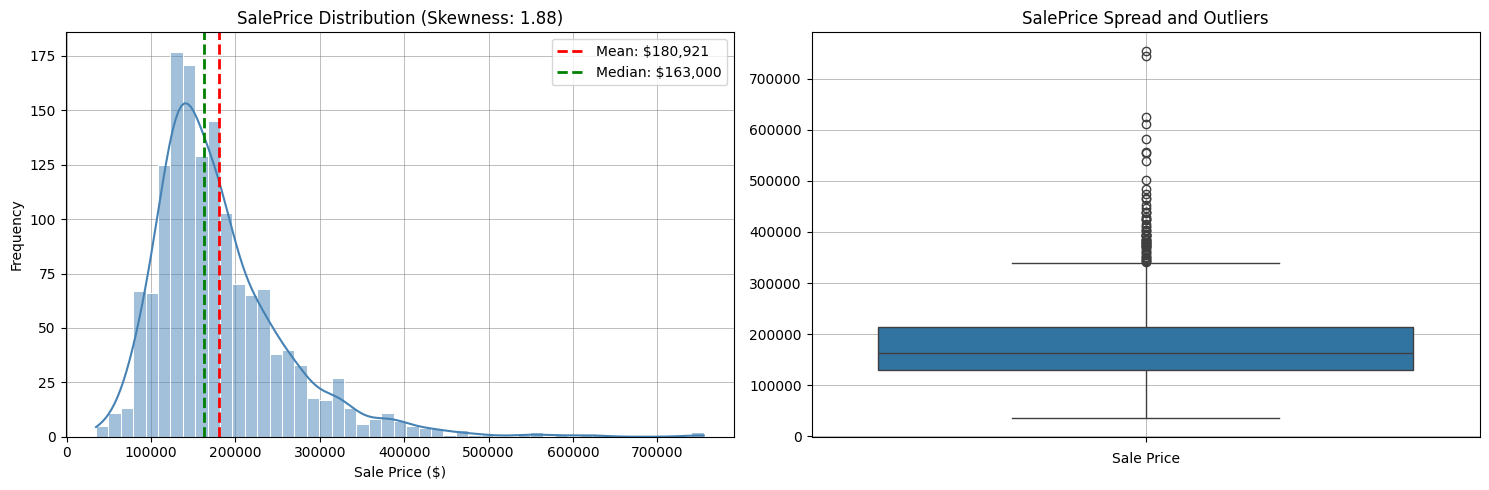

In [19]:
# Calculate key statistics
mean_price = ames_df_imputed["SalePrice"].mean()
median_price = ames_df_imputed["SalePrice"].median()
skewness = stats.skew(ames_df_imputed["SalePrice"])

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Plot 1: Histogram with KDE
sns.histplot(
	data=ames_df_imputed["SalePrice"],
	color="steelblue",
	edgecolor="white",
	kde=True,
	ax=axes[0],
)

# Add vertical lines for mean and median
axes[0].axvline(
	mean_price,
	color="red",
	linestyle="--",
	linewidth=2,
	label=f"Mean: ${mean_price:,.0f}",
)
axes[0].axvline(
	median_price,
	color="green",
	linestyle="--",
	linewidth=2,
	label=f"Median: ${median_price:,.0f}",
)

axes[0].set(
	title=f"SalePrice Distribution (Skewness: {skewness:.2f})",
	xlabel="Sale Price ($)",
	ylabel="Frequency",
)
axes[0].legend()
axes[0].grid(True, alpha=0.6, linewidth=0.6, color="grey")
axes[0].set_axisbelow(True)

# Plot 2: Box plot to show spread and outliers
sns.boxplot(data=ames_df_imputed["SalePrice"], ax=axes[1])
axes[1].set(title="SalePrice Spread and Outliers", xlabel="Sale Price", ylabel="")
axes[1].grid(True, alpha=0.6, linewidth=0.6, color="grey")
axes[1].set_axisbelow(True)

plt.tight_layout()
plt.show()

**3. Analysis: Key Numeric Drivers**

  * **Goal:** Identify which *numeric* features (e.g., square footage, room count, year built) have the strongest and most important relationships with `SalePrice`.
  * **Deliverable:**
      * A summary (visual or tabular) that quantifies the strength of these relationships.
      * A specific visual deep-dive into the *two most important* numeric features.
      * **Answer this:** Are these relationships linear? Are there outliers? Are they monotonic? (You must decide which correlation metric—Pearson or Spearman—is more appropriate).

In [20]:
# Select numeric features
numeric = ames_df_imputed.select_dtypes("number")

# Compute Spearman correlation matrix
spearman_corr_matrix = numeric.corr(method="spearman")

# Extract and sort correlations with SalePrice
spearman_price_corr = spearman_corr_matrix["SalePrice"].sort_values(ascending=False)

# Convert to DataFrame
spearman_price_corr_df = pd.DataFrame({
	"Feature": spearman_price_corr.index,
	"Spearman_Corr_with_SalePrice": spearman_price_corr.values,
})

# Round to 3 decimal places for readability
spearman_price_corr_df["Spearman_Corr_with_SalePrice"] = spearman_price_corr_df[
	"Spearman_Corr_with_SalePrice"
].round(4)

# Display the top 10 (or full with .head(10))
display(spearman_price_corr_df)


,Feature,Spearman_Corr_with_SalePrice
0,SalePrice,1.0000
1,OverallQual,0.8098
2,GrLivArea,0.7313
3,GarageCars,0.6907
4,YearBuilt,0.6527
5,GarageArea,0.6494
6,FullBath,0.6360
7,GarageYrBlt,0.6341
8,TotalBsmtSF,0.6027
9,1stFlrSF,0.5754


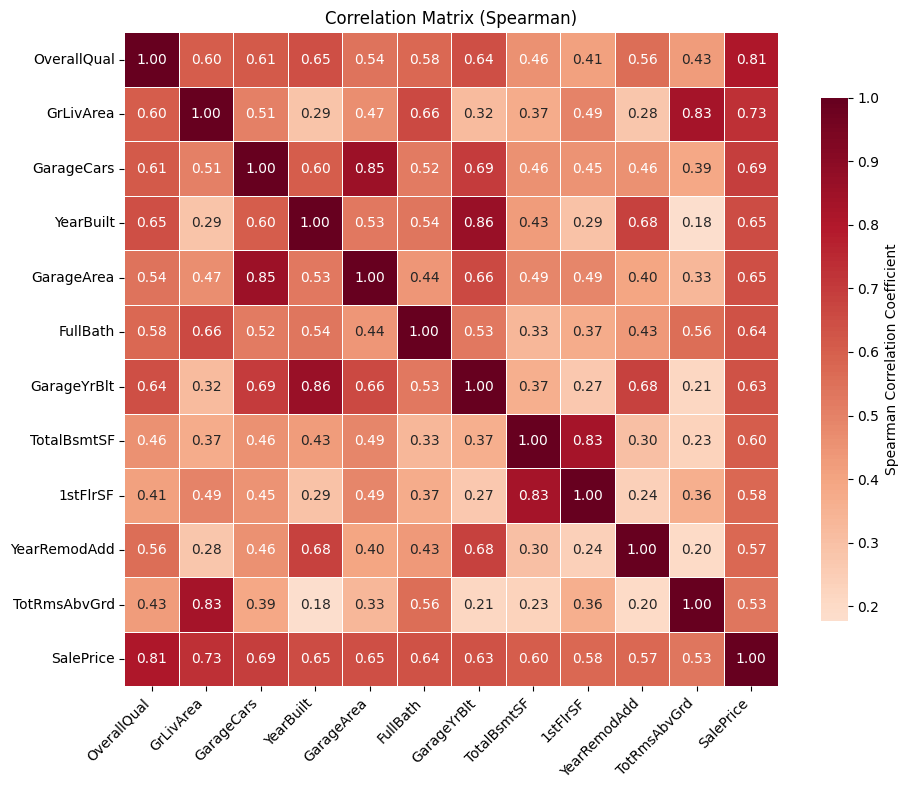

In [ ]:
N = 12
top_features = spearman_price_corr.abs().nlargest(N).index.tolist()
top_features.remove("SalePrice")  # Exclude target
focused_spearman_corr = spearman_corr_matrix.loc[
	top_features + ["SalePrice"], top_features + ["SalePrice"]
]

# Sort rows/columns by descending absolute correlation with SalePrice
order = spearman_price_corr.loc[top_features].abs().sort_values(ascending=False).index
feature_order = list(order) + ["SalePrice"]  # Safe concatenation
focused_spearman_corr_sorted = focused_spearman_corr.loc[feature_order, feature_order]

# Plot the filtered heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(
	focused_spearman_corr_sorted,
	cmap="RdBu_r",  # Diverging colormap: red (positive), blue (negative)
	center=0,
	annot=True,  # Annotate only unmasked cells
	fmt=".2f",
	cbar_kws={"shrink": 0.8, "label": "Spearman Correlation Coefficient"},
	square=True,
	linewidths=0.5,
)
plt.title("Correlation Matrix (Spearman)")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [22]:
numeric = ames_df_imputed.select_dtypes("number")
corr_matrix = numeric.corr()

# Create a focused correlation matrix with SalePrice
price_corr = corr_matrix["SalePrice"].sort_values(ascending=False).head(7)

price_corr_df = pd.DataFrame(
	data={
		"Feature": price_corr.index,
		"Pearson_Corr_with_SalePrice": price_corr.values,
	}
)

price_corr_df["Pearson_Corr_with_SalePrice"] = price_corr_df[
	"Pearson_Corr_with_SalePrice"
].round(4)

display(price_corr_df)


,Feature,Pearson_Corr_with_SalePrice
0,SalePrice,1.0000
1,OverallQual,0.7910
2,GrLivArea,0.7086
3,GarageCars,0.6404
4,GarageArea,0.6234
5,TotalBsmtSF,0.6136
6,1stFlrSF,0.6059


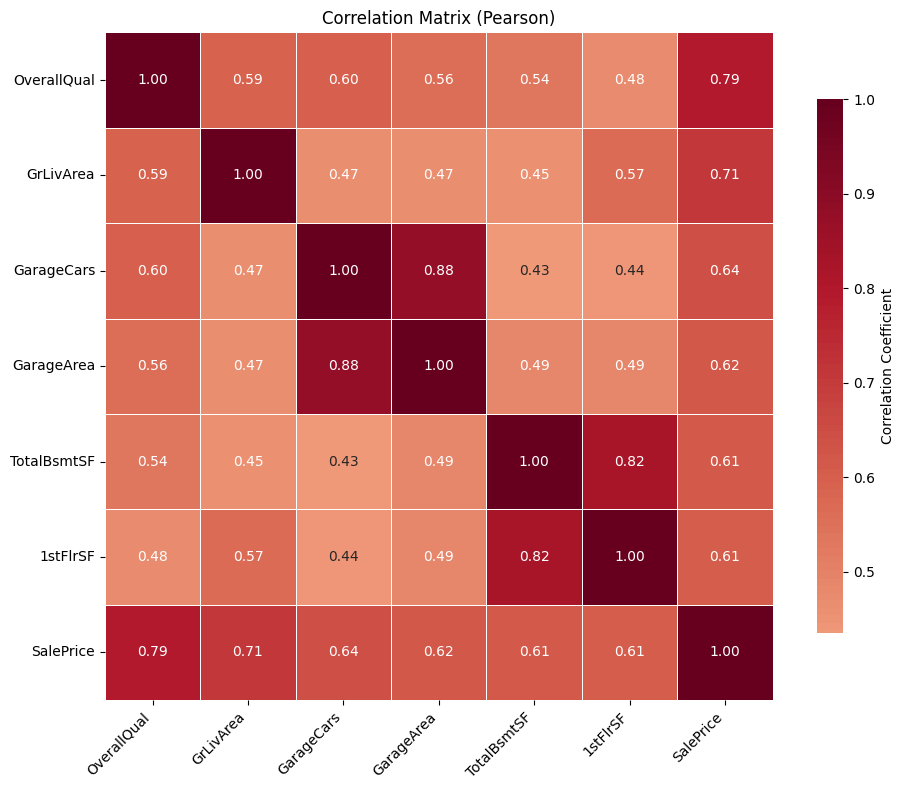

In [ ]:
N = 15
top_features = price_corr.abs().nlargest(N).index.tolist()
top_features.remove("SalePrice")  # Exclude target
focused_corr = corr_matrix.loc[
	top_features + ["SalePrice"], top_features + ["SalePrice"]
]

# Sort rows/columns by descending absolute correlation with SalePrice
order = price_corr.loc[top_features].abs().sort_values(ascending=False).index

# Fix: Convert Index to list before concatenation to avoid string broadcasting
feature_order = list(order) + ["SalePrice"]
focused_corr_sorted = focused_corr.loc[feature_order, feature_order]

# Plot the filtered heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(
	focused_corr_sorted,
	cmap="RdBu_r",  # Diverging colormap: red (positive), blue (negative)
	center=0,
	annot=True,  # Annotate only unmasked cells
	fmt=".2f",
	cbar_kws={"shrink": 0.8, "label": "Correlation Coefficient"},
	square=True,
	linewidths=0.5,
)
plt.title("Correlation Matrix (Pearson)")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


**4. Analysis: Key Categorical Drivers**

  * **Goal:** Identify which *categorical* or *ordinal* features (e.g., `Neighborhood`, `OverallQual`, `KitchenQual`) have the biggest impact on `SalePrice`.
  * **Deliverable:**
      * A visual analysis that compares the `SalePrice` distributions across the groups of (at least) two key categorical features.
      * **Answer this:** Where are the most expensive houses located (`Neighborhood`)?
      * **Answer this:** How much does `OverallQual` (Overall Quality) impact the final price? (Provide visual proof).

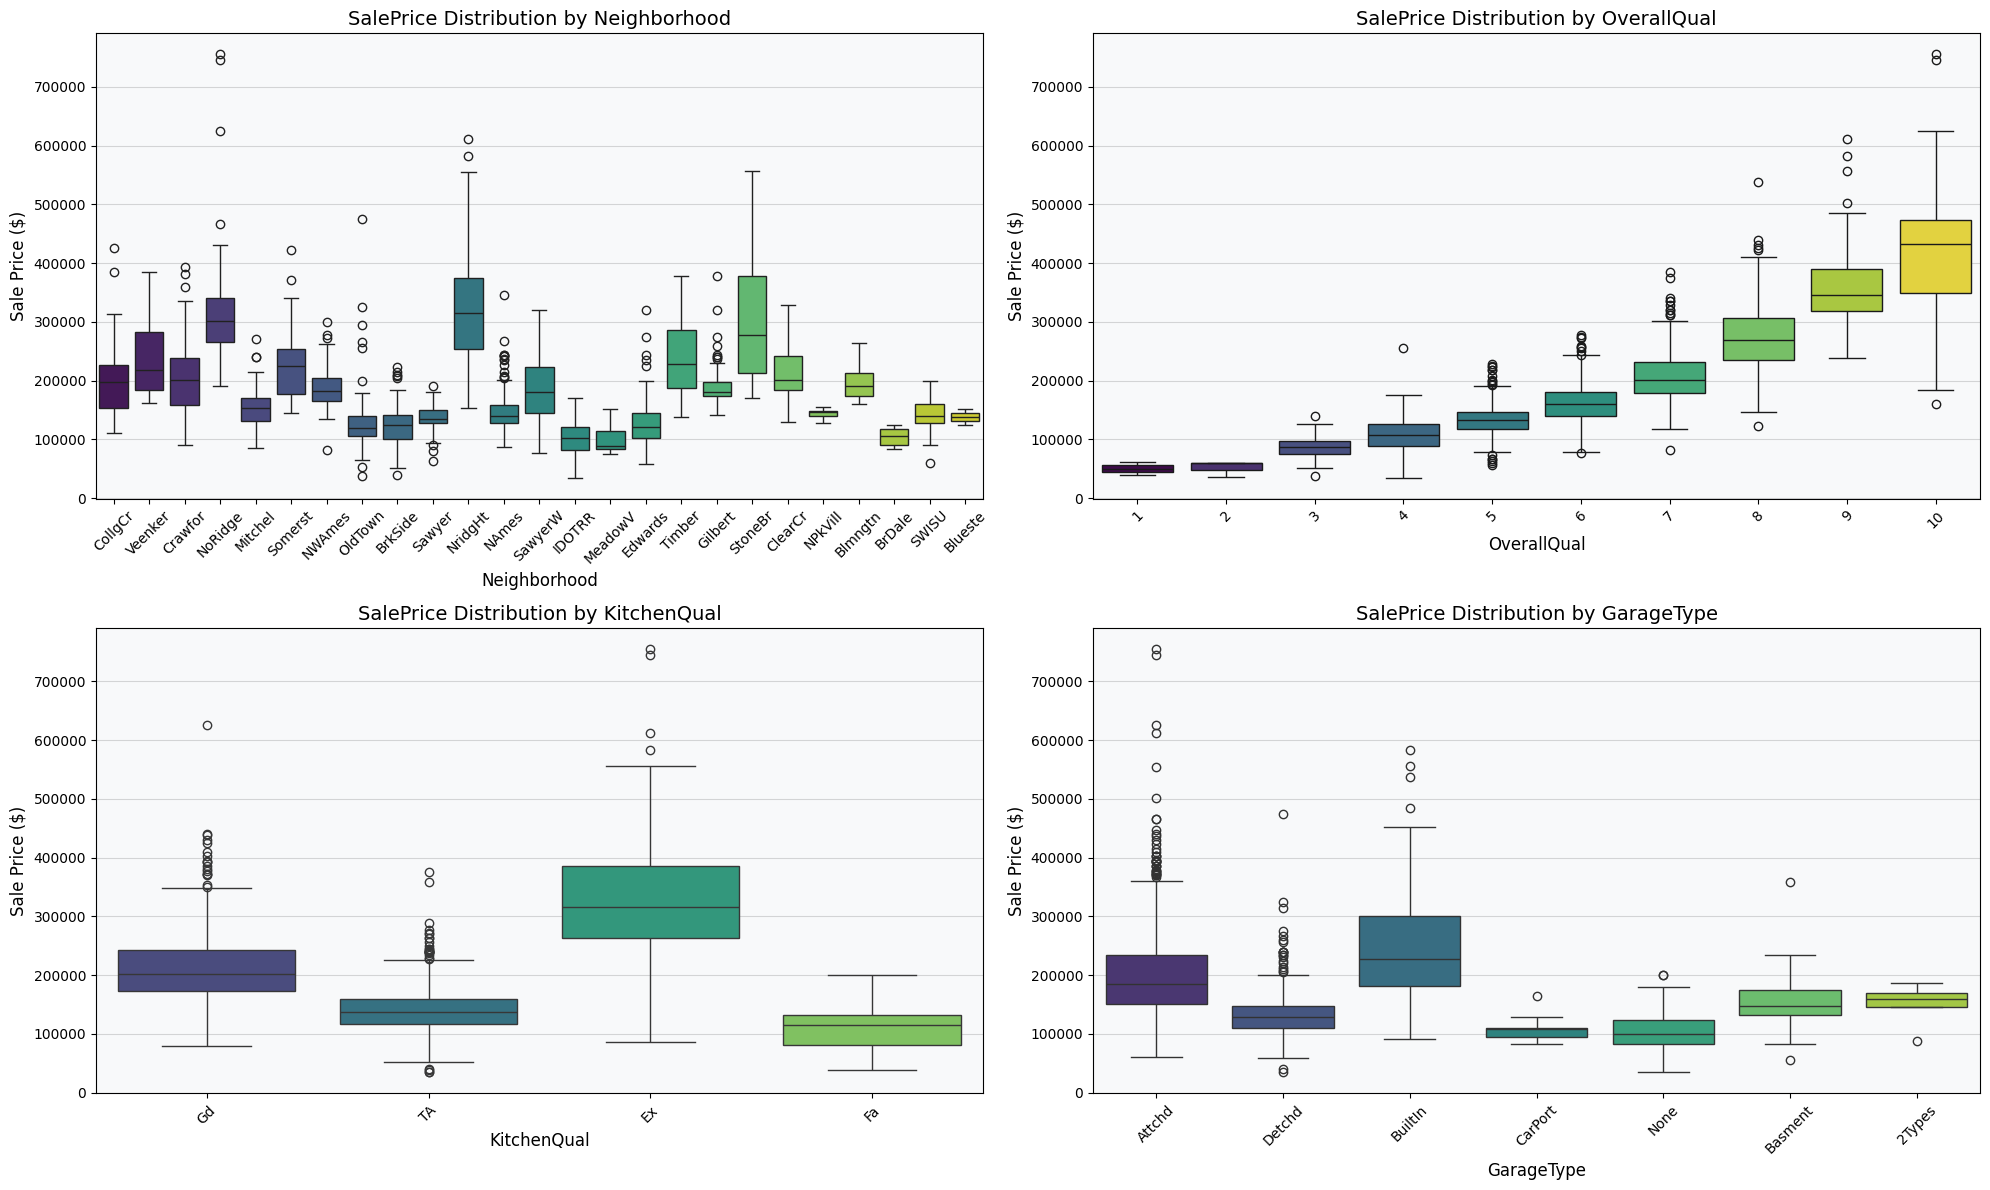

In [24]:
# Select key categorical features for analysis
key_cat_features = ["Neighborhood", "OverallQual", "KitchenQual", "GarageType"]

# Create subplots for each categorical feature
fig, axes = plt.subplots(2, 2, figsize=(20, 12))
axes = axes.ravel()

# Define a color palette
palette = sns.color_palette("husl", n_colors=len(key_cat_features))

for i, feature in enumerate(key_cat_features):
	# Create boxplot showing SalePrice distribution across categories
	sns.boxplot(
		data=ames_df_imputed,
		x=feature,
		y="SalePrice",
		ax=axes[i],
		palette="viridis",  # Use viridis palette for better color differentiation
		hue=feature,  # Use the feature itself as hue for color coding
		legend=False,  # Avoid legend duplication
	)

	# Customize each plot
	axes[i].set_title(f"SalePrice Distribution by {feature}", fontsize=14)
	axes[i].set_xlabel(feature, fontsize=12)
	axes[i].set_ylabel("Sale Price ($)", fontsize=12)

	# Rotate x-axis labels for better readability
	axes[i].tick_params(axis="x", rotation=45)
	axes[i].tick_params(axis="y")

	# Add grid for better readability
	axes[i].grid(True, alpha=0.3, axis="y", color="grey")
	axes[i].set_axisbelow(True)

	# Set facecolor for better visual appeal
	axes[i].set_facecolor("#f8f9fa")

plt.tight_layout()
plt.show()

**5. Feature Engineering & Hypothesis Generation**

  * **Goal:** Use your domain knowledge and statistical insights to create *new* features that are more predictive than the raw data.
  * **Deliverable:**
      * Create at least **two new features**. (For example: what about the total age of the house? Or the total number of bathrooms? Or total square footage?).
      * For each new feature, you must provide:
        1.  The code to create it.
        2.  A 1-2 sentence justification explaining *why* you believe this feature will be more powerful than the originals (e.g., "I created `TotalBath` because...").
        3.  A visual or statistical test (e.g., a correlation test) that *proves* your new feature has a strong relationship with `SalePrice`.

**6. Final Report: Top 5 Hypotheses**

  * **Goal:** Summarize your entire investigation.
  * **Deliverable:** A concise, final report (in a markdown cell) that lists your **Top 5 Hypotheses** for what drives the value of a house in Ames. These must be backed by the evidence you have generated.
      * *Example Hypothesis:* "Hypothesis 1: Above-ground living area (`GrLivArea`) is the single strongest linear driver of price. However, this relationship weakens for very large houses, suggesting a non-linear effect..."

### Review Criteria

When you are finished, I will not be checking if your code "runs." I will be reviewing your work on these four pillars:

1.  **Statistical Rigour:** Did you choose the right metrics (mean vs. median)? Did you correctly identify skew? Did you use the right correlation coefficient?
2.  **Visual Integrity:** Are your charts honest, clear, and do they *support* your argument?
3.  **Pythonic Quality:** Is your code clean, efficient (e.g., vectorized), and DRY?
4.  **Insight:** Did you just "state the obvious" (e.g., "Bigger houses cost more"), or did you find a *nuanced* pattern (e.g., "The *quality* of the kitchen, `KitchenQual`, appears to have a stronger impact on price than the total number of rooms, `TotRmsAbvGrd`")?